# Stage 3: Species Classifier on GT-Cropped Animals

**CPTS 434 — Automated Wildlife Classification (v1: cropped)**

This notebook is the cropped-input rematch of `02_species_classifier.ipynb`. The Stage 2
baseline scored **macro-F1 = 0.219** on `trans_test` because the model was reading the
*camera-location background* more than the animal — at 224 px the animal often occupies
< 10 % of the frame.

**Changes from Stage 2:**

| Knob               | Stage 2 (v0)              | Stage 3 (v1)                                |
|--------------------|---------------------------|---------------------------------------------|
| Input              | full frame, 224 px        | **GT-bbox crop + 10 % pad, 384 px**         |
| Backbone           | ResNet-50 frozen          | ResNet-50, **layer4 unfrozen**              |
| Optimizer          | Adam, single LR 1e-3      | Adam, **discriminative LR** (head/layer4)   |
| Loss               | inverse-freq CE           | **class-balanced CE** (Cui et al. 2019)     |
| Classes            | 15                        | **12** (fox / badger / deer dropped — n<50) |

GT bboxes are present on ~80–90 % of CCT20 annotations; we drop animal images without a
box. Empty frames stay excluded as in Stage 2.

In [1]:
# Standard library
import os, io, json, random, copy, time
from pathlib import Path
from collections import Counter, defaultdict

# Scientific computing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# torchvision
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights

# scikit-learn metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Image loading
from PIL import Image

# Progress bars
from tqdm.notebook import tqdm

print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")

PyTorch     : 2.10.0
torchvision : 0.25.0


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print("Seed set.")

Seed set.


## 1. Setup & Configuration

In [3]:
device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()         else
    "cpu"
)

ANNOTATION_DIR = Path("data/eccv_18_annotation_files")
IMAGE_DIR      = Path("data/eccv_18_all_images_sm")

CONFIG = {
    "train_json"     : ANNOTATION_DIR / "train_annotations.json",
    "val_json"       : ANNOTATION_DIR / "cis_val_annotations.json",
    "cis_test_json"  : ANNOTATION_DIR / "cis_test_annotations.json",
    "trans_test_json": ANNOTATION_DIR / "trans_test_annotations.json",
    "image_dir"      : IMAGE_DIR,

    "checkpoint_dir" : Path("checkpoints/species_cropped"),
    "results_dir"    : Path("results/species_cropped"),

    "seed": 42,

    # ── Crop ───────────────────────────────────────────────────────────────
    # Pad each side of the GT bbox by this fraction before cropping.
    # 0.10 keeps tail/ear context that helps fine-grained ID without diluting
    # the subject with too much background.
    "bbox_pad_frac"  : 0.10,

    # ── Model ──────────────────────────────────────────────────────────────
    "model_name"      : "resnet50",
    "pretrained"      : True,
    # We freeze stem / layers1-3 for the first warmup_frozen_epochs, then
    # unfreeze layer4 with a small LR. The head is always trainable.
    "unfreeze_layer4" : True,
    "warmup_frozen_epochs": 2,

    # ── Training ───────────────────────────────────────────────────────────
    "num_epochs"          : 25,
    "batch_size"          : 32,         # 384 px crops = ~3x memory of 224
    "num_workers"         : 0 if torch.backends.mps.is_available() else 4,
    "lr_head"             : 1e-3,
    "lr_layer4"           : 1e-4,
    "weight_decay"        : 1e-4,
    "lr_patience"         : 3,
    "lr_factor"           : 0.3,
    "early_stop_patience" : 7,
    "image_size"          : 384,

    # ── Class-balanced loss (Cui et al. 2019) ──────────────────────────────
    # Effective number weighting, beta -> 1 approaches inverse-frequency.
    "cb_beta"             : 0.999,

    "device": device,
}

set_seed(CONFIG["seed"])
CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_dir"].mkdir(parents=True, exist_ok=True)

print(f"Device         : {CONFIG['device']}")
print(f"Image size     : {CONFIG['image_size']}")
print(f"Checkpoint dir : {CONFIG['checkpoint_dir']}")
print(f"Results dir    : {CONFIG['results_dir']}")

Device         : mps
Image size     : 384
Checkpoint dir : checkpoints/species_cropped
Results dir    : results/species_cropped


## 2. Class Definitions

We drop the three classes with too few training samples to learn:
`badger` (9), `deer` (45), `fox` (5). They contributed ~0 to macro-F1 in v0 and
mainly added noise to inverse-freq weighting. The headline metric is now **12-class
macro-F1**.

In [4]:
EMPTY_CAT_ID  = 30      # excluded everywhere
DROP_CAT_IDS  = {21, 34, 51}   # badger, deer, fox

# All non-empty CCT20 categories
ALL_CLASS_IDS = [1, 3, 5, 6, 7, 8, 9, 10, 11, 16, 21, 33, 34, 51, 99]
ALL_CLASS_NAMES = ["opossum","raccoon","squirrel","bobcat","skunk","dog","coyote",
                   "rabbit","bird","cat","badger","car","deer","fox","rodent"]

CLASS_IDS   = [c for c in ALL_CLASS_IDS if c not in DROP_CAT_IDS]
CLASS_NAMES = [n for c, n in zip(ALL_CLASS_IDS, ALL_CLASS_NAMES) if c not in DROP_CAT_IDS]
CAT_ID_TO_IDX = {cat_id: idx for idx, cat_id in enumerate(CLASS_IDS)}
NUM_CLASSES   = len(CLASS_IDS)

print(f"Number of classes : {NUM_CLASSES}")
print(f"Dropped           : {[ALL_CLASS_NAMES[ALL_CLASS_IDS.index(c)] for c in DROP_CAT_IDS]}")
for idx, (c, n) in enumerate(zip(CLASS_IDS, CLASS_NAMES)):
    print(f"  {idx:>2}  cat_id={c:<3}  {n}")

Number of classes : 12
Dropped           : ['deer', 'fox', 'badger']
   0  cat_id=1    opossum
   1  cat_id=3    raccoon
   2  cat_id=5    squirrel
   3  cat_id=6    bobcat
   4  cat_id=7    skunk
   5  cat_id=8    dog
   6  cat_id=9    coyote
   7  cat_id=10   rabbit
   8  cat_id=11   bird
   9  cat_id=16   cat
  10  cat_id=33   car
  11  cat_id=99   rodent


## 3. Data Loading — Require GT Bbox

We loop CCT annotations (not images) so that one image with multiple boxes contributes
multiple training crops. An animal image with no bbox is skipped (with a count).

In [5]:
def load_cct20_cropped_split(json_path,
                              cat_id_to_idx=CAT_ID_TO_IDX,
                              empty_cat_id=EMPTY_CAT_ID):
    """Return list of (file_name, bbox_xywh, class_idx).

    bbox is COCO format: [x, y, w, h] in absolute pixels.
    """
    with open(json_path) as f:
        data = json.load(f)

    img_id_to_file = {img["id"]: img["file_name"] for img in data["images"]}

    samples           = []
    skipped_empty     = 0
    skipped_dropped   = 0
    skipped_unknown   = 0
    skipped_no_bbox   = 0

    for ann in data["annotations"]:
        cat_id = ann["category_id"]
        if cat_id == empty_cat_id:
            skipped_empty += 1; continue
        if cat_id in DROP_CAT_IDS:
            skipped_dropped += 1; continue
        if cat_id not in cat_id_to_idx:
            skipped_unknown += 1; continue
        bbox = ann.get("bbox")
        if not bbox or len(bbox) != 4 or bbox[2] <= 1 or bbox[3] <= 1:
            skipped_no_bbox += 1; continue
        file_name = img_id_to_file.get(ann["image_id"])
        if file_name is None:
            continue
        samples.append((file_name, list(bbox), cat_id_to_idx[cat_id]))

    counts = Counter(idx for _, _, idx in samples)
    print(f"  {json_path.name}: {len(samples):,} crops "
          f"(empty={skipped_empty:,}, dropped_class={skipped_dropped:,}, "
          f"no_bbox={skipped_no_bbox:,})")
    for idx, name in enumerate(CLASS_NAMES):
        print(f"    {idx:2d}  {name:10s}: {counts.get(idx,0):>5,}")
    return samples


print("Loading splits ...")
train_samples    = load_cct20_cropped_split(CONFIG["train_json"])
val_samples      = load_cct20_cropped_split(CONFIG["val_json"])
cis_test_samples = load_cct20_cropped_split(CONFIG["cis_test_json"])
trans_test_samples = load_cct20_cropped_split(CONFIG["trans_test_json"])

print(f"\nTotals — train: {len(train_samples):,} | val: {len(val_samples):,} | "
      f"cis_test: {len(cis_test_samples):,} | trans_test: {len(trans_test_samples):,}")

Loading splits ...
  train_annotations.json: 12,559 crops (empty=0, dropped_class=59, no_bbox=1,453)
     0  opossum   : 2,514
     1  raccoon   : 1,030
     2  squirrel  : 1,037
     3  bobcat    :   684
     4  skunk     :   214
     5  dog       :   769
     6  coyote    : 1,371
     7  rabbit    : 2,278
     8  bird      :   560
     9  cat       : 1,170
    10  car       :   668
    11  rodent    :   264
  cis_val_annotations.json: 1,760 crops (empty=995, dropped_class=4, no_bbox=823)
     0  opossum   :   358
     1  raccoon   :   126
     2  squirrel  :   150
     3  bobcat    :    92
     4  skunk     :    24
     5  dog       :   106
     6  coyote    :   200
     7  rabbit    :   366
     8  bird      :    82
     9  cat       :   169
    10  car       :    41
    11  rodent    :    46


  cis_test_annotations.json: 13,118 crops (empty=1,180, dropped_class=170, no_bbox=1,927)
     0  opossum   : 4,010
     1  raccoon   :   981
     2  squirrel  :   510
     3  bobcat    :   772
     4  skunk     :   162
     5  dog       :   725
     6  coyote    : 1,182
     7  rabbit    : 1,559
     8  bird      :   752
     9  cat       : 1,528
    10  car       :   791
    11  rodent    :   146


  trans_test_annotations.json: 18,770 crops (empty=1,778, dropped_class=17, no_bbox=3,463)
     0  opossum   : 4,663
     1  raccoon   : 4,803
     2  squirrel  :   782
     3  bobcat    : 1,979
     4  skunk     :   273
     5  dog       :   961
     6  coyote    : 1,902
     7  rabbit    :   722
     8  bird      :   180
     9  cat       : 1,366
    10  car       : 1,113
    11  rodent    :    26

Totals — train: 12,559 | val: 1,760 | cis_test: 13,118 | trans_test: 18,770


## 4. Cropped Dataset Class

Crop is applied **in `__getitem__`**, so we never write cropped JPEGs to disk. The box
is padded by `bbox_pad_frac` on each side and clipped to image bounds.

In [6]:
class CroppedCameraTrapsDataset(Dataset):
    def __init__(self, samples, image_dir, transform=None,
                 pad_frac: float = 0.10):
        self.samples   = samples
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.pad_frac  = pad_frac

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_name, bbox, label = self.samples[idx]
        x, y, w, h = bbox

        path = self.image_dir / file_name
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"[WARN] {path}: {e}")
            img = Image.new("RGB", (CONFIG["image_size"], CONFIG["image_size"]), (0, 0, 0))
            return (self.transform(img) if self.transform else img,
                    torch.tensor(label, dtype=torch.long))

        W, H = img.size
        pad_x = w * self.pad_frac
        pad_y = h * self.pad_frac
        x1 = max(0, int(round(x - pad_x)))
        y1 = max(0, int(round(y - pad_y)))
        x2 = min(W, int(round(x + w + pad_x)))
        y2 = min(H, int(round(y + h + pad_y)))
        if x2 <= x1 or y2 <= y1:    # pathological box — fall back to full frame
            x1, y1, x2, y2 = 0, 0, W, H

        crop = img.crop((x1, y1, x2, y2))
        if self.transform:
            crop = self.transform(crop)
        return crop, torch.tensor(label, dtype=torch.long)

    def get_labels(self):
        return [lbl for _, _, lbl in self.samples]


print("CroppedCameraTrapsDataset defined.")

CroppedCameraTrapsDataset defined.


## 5. Sanity Grid — Verify the Crops Look Right

If the animals aren't centered and recognizable here, nothing else matters.

Saved results/species_cropped/sample_grid_cropped.png


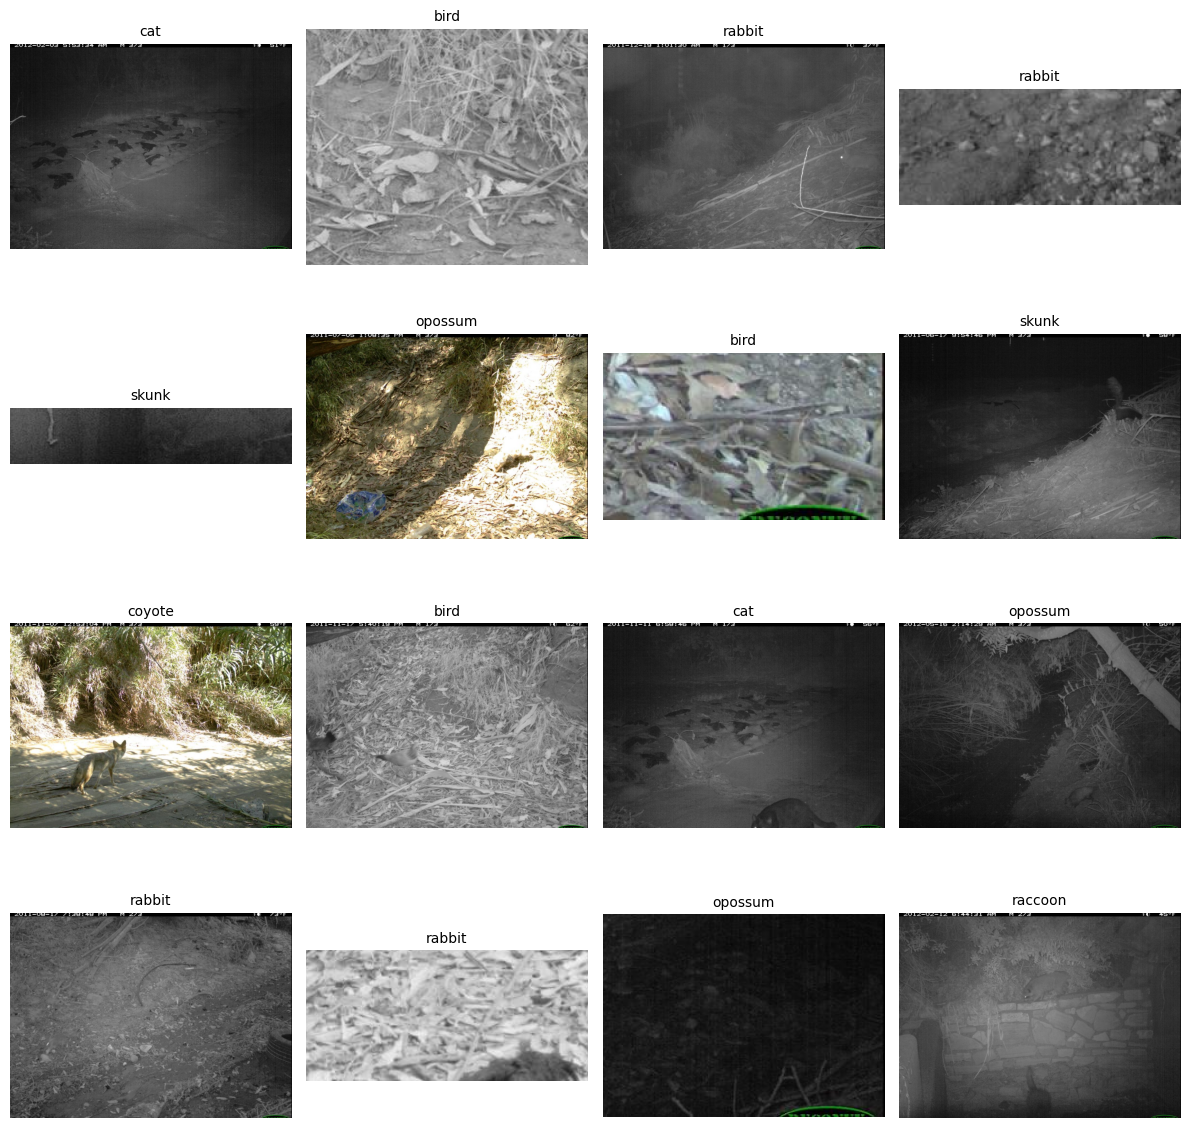

In [7]:
def show_sample_grid(samples, n=16, cols=4, save_path=None,
                     pad_frac=CONFIG["bbox_pad_frac"]):
    rng = random.Random(0)
    picks = rng.sample(samples, min(n, len(samples)))
    rows = (len(picks) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for ax, (fname, bbox, label) in zip(axes, picks):
        path = IMAGE_DIR / fname
        img = Image.open(path).convert("RGB")
        W, H = img.size
        x, y, w, h = bbox
        pad_x, pad_y = w * pad_frac, h * pad_frac
        x1 = max(0, int(round(x - pad_x))); y1 = max(0, int(round(y - pad_y)))
        x2 = min(W, int(round(x + w + pad_x))); y2 = min(H, int(round(y + h + pad_y)))
        if x2 <= x1 or y2 <= y1:
            x1, y1, x2, y2 = 0, 0, W, H
        crop = img.crop((x1, y1, x2, y2))
        ax.imshow(crop)
        ax.set_title(CLASS_NAMES[label], fontsize=10)
        ax.axis("off")
    for ax in axes[len(picks):]:
        ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches="tight")
        print(f"Saved {save_path}")
    plt.show()


show_sample_grid(train_samples, n=16,
                 save_path=CONFIG["results_dir"] / "sample_grid_cropped.png")

## 6. Transforms & DataLoaders

Training augmentations are a bit gentler than v0 because the crop already removes
most of the background context. We still want flip + color jitter for invariance.
A `WeightedRandomSampler` rebalances the mini-batches.

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SZ = CONFIG["image_size"]

train_transform = transforms.Compose([
    transforms.Resize((int(SZ * 1.15), int(SZ * 1.15))),
    transforms.RandomCrop(SZ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds      = CroppedCameraTrapsDataset(train_samples,      IMAGE_DIR, train_transform, CONFIG["bbox_pad_frac"])
val_ds        = CroppedCameraTrapsDataset(val_samples,        IMAGE_DIR, eval_transform,  CONFIG["bbox_pad_frac"])
cis_test_ds   = CroppedCameraTrapsDataset(cis_test_samples,   IMAGE_DIR, eval_transform,  CONFIG["bbox_pad_frac"])
trans_test_ds = CroppedCameraTrapsDataset(trans_test_samples, IMAGE_DIR, eval_transform,  CONFIG["bbox_pad_frac"])

# WeightedRandomSampler for balanced mini-batches
train_labels   = train_ds.get_labels()
label_counts   = Counter(train_labels)
n_total        = len(train_labels)
class_weights  = {c: n_total / cnt for c, cnt in label_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

_pin = CONFIG["device"].type == "cuda"
nw   = CONFIG["num_workers"]

train_loader      = DataLoader(train_ds,      batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=nw, pin_memory=_pin)
val_loader        = DataLoader(val_ds,        batch_size=CONFIG["batch_size"], shuffle=False,   num_workers=nw, pin_memory=_pin)
cis_test_loader   = DataLoader(cis_test_ds,   batch_size=CONFIG["batch_size"], shuffle=False,   num_workers=nw, pin_memory=_pin)
trans_test_loader = DataLoader(trans_test_ds, batch_size=CONFIG["batch_size"], shuffle=False,   num_workers=nw, pin_memory=_pin)

print(f"Train      : {len(train_loader):>4} batches  ({len(train_ds):,} crops)")
print(f"Val        : {len(val_loader):>4} batches  ({len(val_ds):,} crops)")
print(f"Cis-test   : {len(cis_test_loader):>4} batches  ({len(cis_test_ds):,} crops)")
print(f"Trans-test : {len(trans_test_loader):>4} batches  ({len(trans_test_ds):,} crops)")

Train      :  393 batches  (12,559 crops)
Val        :   55 batches  (1,760 crops)
Cis-test   :  410 batches  (13,118 crops)
Trans-test :  587 batches  (18,770 crops)


## 7. Model — ResNet-50, Layer4 Unfrozen

Stem and layers 1–3 are frozen (generic ImageNet edges/textures transfer fine);
layer4 is fine-tuned at a low LR; the new FC head is trained at a higher LR.

In [9]:
def build_model(config, num_classes):
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    # freeze everything by default
    for p in model.parameters():
        p.requires_grad = False

    # head: always trainable
    in_features = model.fc.in_features
    model.fc    = nn.Linear(in_features, num_classes)
    for p in model.fc.parameters():
        p.requires_grad = True

    # layer4 trainable if requested (will start frozen during warmup, see train loop)
    if config["unfreeze_layer4"]:
        for p in model.layer4.parameters():
            p.requires_grad = True

    model = model.to(config["device"])

    n_total     = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model       : ResNet-50 ({num_classes}-class head)")
    print(f"Total       : {n_total:,}")
    print(f"Trainable   : {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)")
    return model


model = build_model(CONFIG, NUM_CLASSES)

Model       : ResNet-50 (12-class head)
Total       : 23,532,620
Trainable   : 14,989,324  (63.7%)


## 8. Class-Balanced Loss + Discriminative LR

**Class-balanced weighting** (Cui et al., CVPR 2019) uses the *effective number* of
samples instead of raw inverse frequency:

$$ w_c \;\propto\; \frac{1 - \beta}{1 - \beta^{n_c}}, \quad \beta = 0.999 $$

This is much gentler on the long tail than `1 / n_c` (which gives a 5-sample class a
weight ~370× larger than a 2,500-sample class — pure gradient noise).

**Discriminative LR**: the FC head is randomly initialized so it needs a higher LR;
layer4 is pretrained and only needs a gentle nudge.

In [10]:
def class_balanced_weights(label_counts, num_classes, beta: float):
    eff_num = np.array([(1.0 - beta ** label_counts.get(c, 1)) / (1.0 - beta)
                        for c in range(num_classes)])
    w = 1.0 / eff_num
    w = w / w.sum() * num_classes      # normalize so mean weight = 1
    return w


cb_w = class_balanced_weights(label_counts, NUM_CLASSES, CONFIG["cb_beta"])
print("Class-balanced weights (beta = {:.3f}):".format(CONFIG["cb_beta"]))
for idx, (n, w) in enumerate(zip(
    [label_counts.get(c, 0) for c in range(NUM_CLASSES)], cb_w)):
    print(f"  {idx:>2}  {CLASS_NAMES[idx]:<10}  n={n:>5,}  w={w:6.3f}")

class_weight_tensor = torch.tensor(cb_w, dtype=torch.float32, device=CONFIG["device"])
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)

# Discriminative LR via param groups
head_params   = list(model.fc.parameters())
layer4_params = list(model.layer4.parameters()) if CONFIG["unfreeze_layer4"] else []

optimizer = optim.Adam(
    [
        {"params": head_params,   "lr": CONFIG["lr_head"]},
        {"params": layer4_params, "lr": CONFIG["lr_layer4"]},
    ],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=CONFIG["lr_patience"], factor=CONFIG["lr_factor"]
)

print(f"\nOptimizer : Adam, lr_head={CONFIG['lr_head']}, lr_layer4={CONFIG['lr_layer4']}")
print(f"Scheduler : ReduceLROnPlateau(mode=max, patience={CONFIG['lr_patience']})")

Class-balanced weights (beta = 0.999):
   0  opossum     n=2,514  w= 0.505
   1  raccoon     n=1,030  w= 0.722
   2  squirrel    n=1,037  w= 0.719
   3  bobcat      n=  684  w= 0.937
   4  skunk       n=  214  w= 2.408
   5  dog         n=  769  w= 0.865
   6  coyote      n=1,371  w= 0.622
   7  rabbit      n=2,278  w= 0.517
   8  bird        n=  560  w= 1.082
   9  cat         n=1,170  w= 0.673
  10  car         n=  668  w= 0.952
  11  rodent      n=  264  w= 1.999

Optimizer : Adam, lr_head=0.001, lr_layer4=0.0001
Scheduler : ReduceLROnPlateau(mode=max, patience=3)


## 9. Training Loop

A 2-epoch warmup keeps layer4 frozen so the random head can land somewhere reasonable
before backprop reaches the backbone. After that, layer4 unfreezes and full
discriminative-LR training kicks in.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total   += y.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.3f}"})
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0; correct = 0; total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="[Val]", leave=False):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            running_loss += loss.item() * x.size(0)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return running_loss / total, correct / total, macro_f1, np.array(all_preds), np.array(all_labels)


def set_layer4_frozen(model, frozen: bool):
    for p in model.layer4.parameters():
        p.requires_grad = not frozen


# ── Warmup: freeze layer4 for the first N epochs ──────────────────────────
if CONFIG["unfreeze_layer4"] and CONFIG["warmup_frozen_epochs"] > 0:
    set_layer4_frozen(model, frozen=True)
    print(f"Warmup: layer4 frozen for {CONFIG['warmup_frozen_epochs']} epochs")

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_macro_f1":[]}
best_val_f1 = -1.0
best_state  = None
best_epoch  = 0
no_improve  = 0
ckpt_path   = CONFIG["checkpoint_dir"] / "best_model.pth"

print(f"Training for up to {CONFIG['num_epochs']} epochs on {CONFIG['device']}")
print("-" * 80)

for epoch in range(1, CONFIG["num_epochs"] + 1):
    if (CONFIG["unfreeze_layer4"]
            and epoch == CONFIG["warmup_frozen_epochs"] + 1):
        set_layer4_frozen(model, frozen=False)
        n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  → unfreezing layer4 (trainable params now {n_train:,})")

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, CONFIG["device"], epoch)
    va_loss, va_acc, va_f1, _, _ = validate(model, val_loader, criterion, CONFIG["device"])
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["val_macro_f1"].append(va_f1)

    scheduler.step(va_f1)

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        best_epoch  = epoch
        no_improve  = 0
        best_state  = copy.deepcopy(model.state_dict())
        torch.save({
            "epoch": epoch,
            "model_state_dict": best_state,
            "val_macro_f1": va_f1,
            "class_names": CLASS_NAMES,
            "cat_id_to_idx": CAT_ID_TO_IDX,
            "config": {k: str(v) for k, v in CONFIG.items()},
        }, ckpt_path)
        marker = "  ← best"
    else:
        no_improve += 1
        marker = ""

    lr_head = optimizer.param_groups[0]["lr"]
    lr_l4   = optimizer.param_groups[1]["lr"] if len(optimizer.param_groups) > 1 else 0.0
    print(f"E{epoch:>2}/{CONFIG['num_epochs']} | loss {tr_loss:.3f}/{va_loss:.3f} | "
          f"acc {tr_acc:.3f}/{va_acc:.3f} | val mF1 {va_f1:.4f} | "
          f"lr {lr_head:.1e}/{lr_l4:.1e} | {elapsed:.1f}s{marker}")

    if no_improve >= CONFIG["early_stop_patience"]:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest val macro-F1 = {best_val_f1:.4f} at epoch {best_epoch}")
print(f"Checkpoint        : {ckpt_path}")

Warmup: layer4 frozen for 2 epochs
Training for up to 25 epochs on mps
--------------------------------------------------------------------------------


Epoch 1 [Train]:   0%|          | 0/393 [00:00<?, ?it/s]

[Val]:   0%|          | 0/55 [00:00<?, ?it/s]

E 1/25 | loss 1.336/1.538 | acc 0.453/0.394 | val mF1 0.4416 | lr 1.0e-03/1.0e-04 | 213.5s  ← best


Epoch 2 [Train]:   0%|          | 0/393 [00:00<?, ?it/s]

...

[Val]:   0%|          | 0/55 [00:00<?, ?it/s]

E24/25 | loss 0.138/1.055 | acc 0.930/0.737 | val mF1 0.7359 | lr 1.0e-03/1.0e-04 | 235.3s


Epoch 25 [Train]:   0%|          | 0/393 [00:00<?, ?it/s]

[Val]:   0%|          | 0/55 [00:00<?, ?it/s]

E25/25 | loss 0.154/0.961 | acc 0.927/0.761 | val mF1 0.7729 | lr 3.0e-04/3.0e-05 | 227.8s

Best val macro-F1 = 0.8029 at epoch 21
Checkpoint        : checkpoints/species_cropped/best_model.pth


## 10. Training Curves

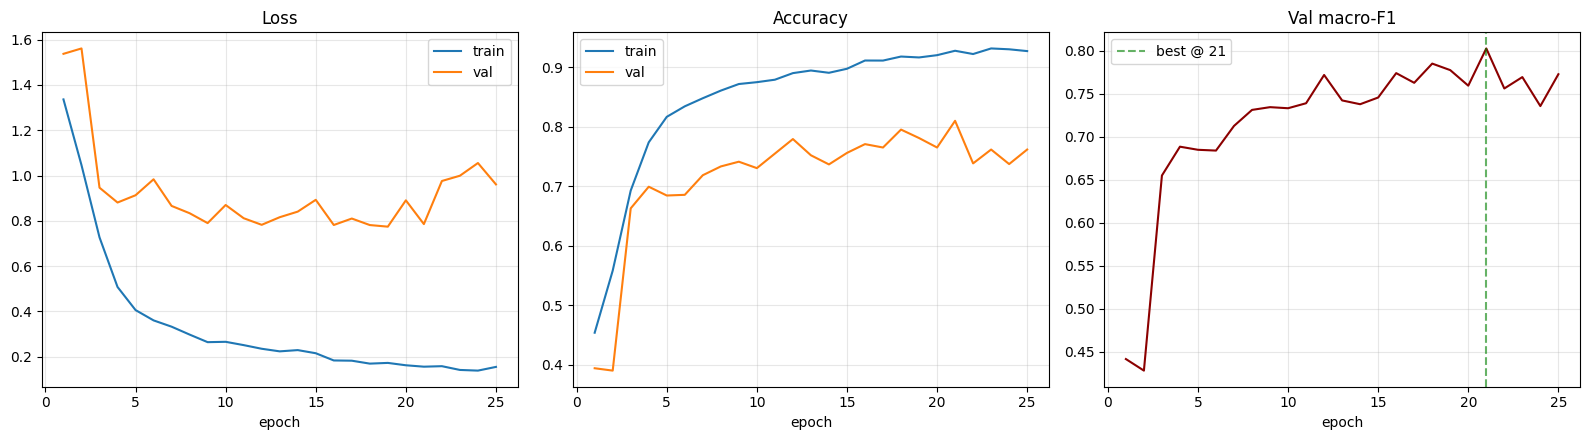

In [12]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_acc"], label="train")
axes[1].plot(epochs_ran, history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history["val_macro_f1"], color="darkred")
axes[2].axvline(best_epoch, color="green", linestyle="--", alpha=0.6, label=f"best @ {best_epoch}")
axes[2].set_title("Val macro-F1"); axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG["results_dir"] / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()

## 11. Final Evaluation — Cis-Test & Trans-Test

In [13]:
# Reload best checkpoint
ckpt = torch.load(ckpt_path, map_location=CONFIG["device"], weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val mF1 = {ckpt['val_macro_f1']:.4f})")


def evaluate_split(name, loader):
    _, acc, mF1, preds, labels = validate(model, loader, criterion, CONFIG["device"])
    print(f"\n{name}:")
    print(f"  accuracy : {acc:.4f}")
    print(f"  macro F1 : {mF1:.4f}")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0, digits=3))
    return preds, labels, mF1


cis_preds,   cis_labels,   cis_f1   = evaluate_split("CIS-TEST",   cis_test_loader)
trans_preds, trans_labels, trans_f1 = evaluate_split("TRANS-TEST", trans_test_loader)

Loaded best checkpoint from epoch 21 (val mF1 = 0.8029)


[Val]:   0%|          | 0/410 [00:00<?, ?it/s]


CIS-TEST:
  accuracy : 0.6695
  macro F1 : 0.6311
              precision    recall  f1-score   support

     opossum      0.850     0.639     0.730      4010
     raccoon      0.463     0.833     0.595       981
    squirrel      0.492     0.494     0.493       510
      bobcat      0.601     0.703     0.648       772
       skunk      0.294     0.728     0.419       162
         dog      0.625     0.479     0.542       725
      coyote      0.742     0.640     0.688      1182
      rabbit      0.648     0.742     0.692      1559
        bird      0.803     0.578     0.672       752
         cat      0.542     0.620     0.578      1528
         car      0.981     0.997     0.989       791
      rodent      0.873     0.377     0.526       146

    accuracy                          0.669     13118
   macro avg      0.660     0.653     0.631     13118
weighted avg      0.709     0.669     0.676     13118



[Val]:   0%|          | 0/587 [00:00<?, ?it/s]


TRANS-TEST:
  accuracy : 0.4929
  macro F1 : 0.3883
              precision    recall  f1-score   support

     opossum      0.732     0.563     0.636      4663
     raccoon      0.692     0.531     0.601      4803
    squirrel      0.354     0.495     0.413       782
      bobcat      0.511     0.208     0.295      1979
       skunk      0.142     0.495     0.220       273
         dog      0.543     0.545     0.544       961
      coyote      0.421     0.410     0.415      1902
      rabbit      0.165     0.494     0.247       722
        bird      0.077     0.161     0.104       180
         cat      0.167     0.264     0.205      1366
         car      0.973     0.983     0.978      1113
      rodent      0.000     0.000     0.000        26

    accuracy                          0.493     18770
   macro avg      0.398     0.429     0.388     18770
weighted avg      0.577     0.493     0.517     18770



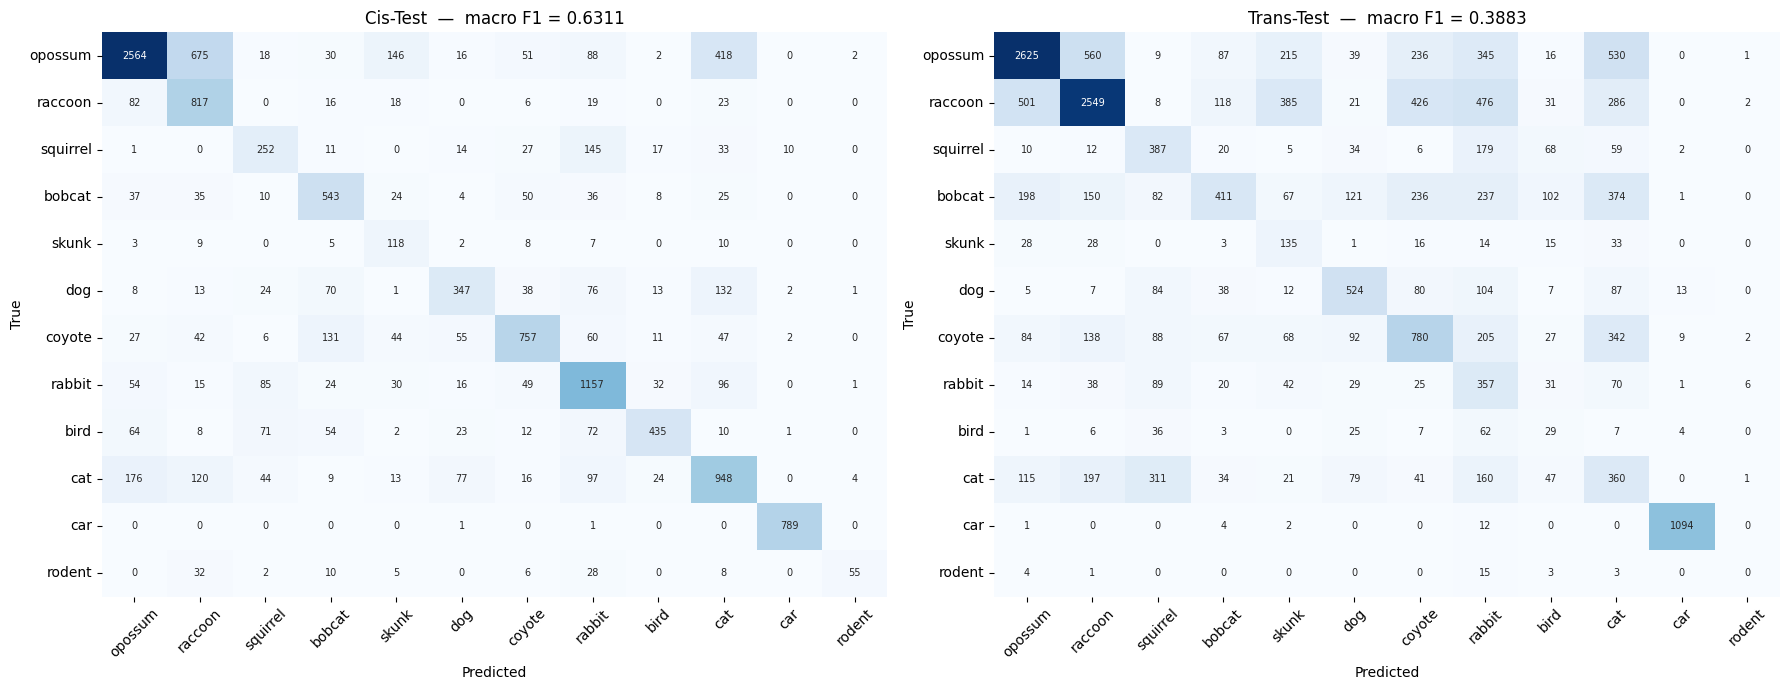

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (name, preds, labels, mF1) in zip(axes, [
    ("Cis-Test",   cis_preds,   cis_labels,   cis_f1),
    ("Trans-Test", trans_preds, trans_labels, trans_f1),
]):
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={"size": 7})
    ax.set_title(f"{name}  —  macro F1 = {mF1:.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(CONFIG["results_dir"] / "confusion_matrices.png", dpi=140, bbox_inches="tight")
plt.show()

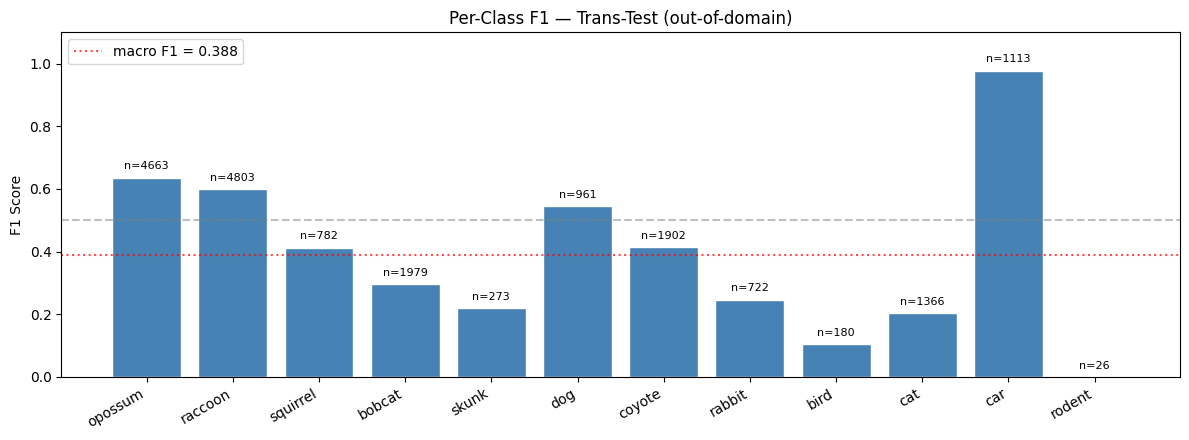

In [15]:
# Per-class F1 — trans-test (the hard one)
from sklearn.metrics import f1_score as _f1
per_class_f1 = _f1(trans_labels, trans_preds,
                   labels=list(range(NUM_CLASSES)),
                   average=None, zero_division=0)
ns = [int((trans_labels == i).sum()) for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(CLASS_NAMES, per_class_f1, color="steelblue", edgecolor="white")
for bar, n in zip(bars, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"n={n}", ha="center", va="bottom", fontsize=8)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.axhline(trans_f1, color="red", linestyle=":", alpha=0.7, label=f"macro F1 = {trans_f1:.3f}")
ax.set_ylim(0, 1.1); ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 — Trans-Test (out-of-domain)")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CONFIG["results_dir"] / "per_class_f1.png", dpi=140, bbox_inches="tight")
plt.show()

In [16]:
# Comparison vs. v0 baseline
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"  v0 baseline (full frame, frozen, 15-cls): trans macro-F1 = 0.219")
print(f"  v1 cropped  ({NUM_CLASSES}-cls, layer4 fine-tuned, 384px crop):")
print(f"    cis-test   macro-F1 = {cis_f1:.4f}")
print(f"    trans-test macro-F1 = {trans_f1:.4f}")
print()
print(f"  Note: v1 evaluates on {NUM_CLASSES} classes (dropped fox/badger/deer).")
print(f"  v0's trans macro-F1 averaged over 15 classes including 0.0s on the dropped ones,")
print(f"  so a fair re-computation of v0 over the same 12 classes would be:")
print(f"    v0 (12-cls reweighted) ≈ 0.219 * 15 / 12 = {0.219 * 15 / 12:.3f}")
print()
print(f"  Either way the comparison should be lopsided in v1's favor if cropping works.")

RESULTS SUMMARY
  v0 baseline (full frame, frozen, 15-cls): trans macro-F1 = 0.219
  v1 cropped  (12-cls, layer4 fine-tuned, 384px crop):
    cis-test   macro-F1 = 0.6311
    trans-test macro-F1 = 0.3883

  Note: v1 evaluates on 12 classes (dropped fox/badger/deer).
  v0's trans macro-F1 averaged over 15 classes including 0.0s on the dropped ones,
  so a fair re-computation of v0 over the same 12 classes would be:
    v0 (12-cls reweighted) ≈ 0.219 * 15 / 12 = 0.274

  Either way the comparison should be lopsided in v1's favor if cropping works.
